# Predictive Modeling with Multi-Modal Data

In [30]:
# Installing needed libraries
!pip install spacy scikit-learn pandas matplotlib seaborn
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 71.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [31]:
#Importing needed Libraries
import pandas as pd
import numpy as np
import spacy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
# Load datasets
path = "/content/drive/My Drive/Amazon Food review/"
reviews_df = pd.read_csv(path + "Reviews.csv")
reviews_df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [34]:
review_text = reviews_df['Text'].tolist()
review_text[:5]

['I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.',
 'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".',
 'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.',
 'If you are looking f

In [35]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary resources from NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
# Download the 'punkt_tab' data package
nltk.download('punkt_tab') # This line is added to download the missing data

# Initialize resources
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [36]:
def preprocess_text(text):
    """
    Cleans and preprocesses a given text.

    Steps:
    1. Remove special characters, URLs, and excessive whitespace.
    2. Normalize text (convert to lowercase).
    3. Tokenize and remove stopwords.
    4. Apply lemmatization for uniformity.
    """
    # Step 1: Remove special characters, URLs, and excessive whitespace
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^\w\s]', '', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove excessive whitespace

    # Step 2: Normalize text
    text = text.lower()

    # Step 3: Tokenize and remove stopwords
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # Step 4: Apply lemmatization
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    # Join tokens back into a string
    processed_text = ' '.join(lemmatized_tokens)
    return processed_text

# Example usage


In [37]:
cleaned_reviews = [preprocess_text(review ) for review in review_text]


# Display results
for i, review in enumerate(cleaned_reviews):
    print(f"Original: {review_text[i]}")
    print(f"Cleaned: {review}\n")

Streaming output truncated to the last 5000 lines.
Cleaned: ghost pepper version daves great lingering heat rise excellent flavor enhances rather hide taste food mention lingering heat great sauce familiar distinctive daves taste lean little toward sweet away bitter original daves personally prefer slight shift toward sweet food ive tried sauce keep continuing use original hotdog perogies chili etc

Original: I have been a fan of Dave's original insanity sauce for years. Heck, it's economical. All I need is one drop into whatever it is I am eating or cooking, and I am done. With other hot sauces, I would go through an entire bottle in a week. What made me a fan of Dave's hot sauces, is the smoky flavor that still comes through despite the heat.<br /><br />My last bottle of Dave's original insanity sauce was running out, and I thought I'd give a different one a try. I decided on the Ghost Pepper hot sauce because it has good review and free shipping from Amazon. I received the shipment 

In [38]:
len(cleaned_reviews)

568454

In [39]:
from transformers import pipeline
# Load pre-trained sentiment-analysis model with truncation enabled
sentiment_analyzer = pipeline("sentiment-analysis", truncation=True)

# Limit to the first 10 reviews (or adjust as needed)
sample_reviews = cleaned_reviews[:1000]  # Analyze only the first 10 reviews

# Analyze sentiment for the selected reviews
sample_sentiment_scores = sentiment_analyzer(sample_reviews)

# Display sentiment results for the selected reviews
for review, sentiment in zip(sample_reviews, sample_sentiment_scores):
    print(f"Review: {review}")
    print(f"Sentiment: {sentiment['label']} | Score: {sentiment['score']:.2f}\n")



No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


Review: bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better
Sentiment: POSITIVE | Score: 0.67

Review: product arrived labeled jumbo salted peanutsthe peanut actually small sized unsalted sure error vendor intended represent product jumbo
Sentiment: NEGATIVE | Score: 1.00

Review: confection around century light pillowy citrus gelatin nut case filbert cut tiny square liberally coated powdered sugar tiny mouthful heaven chewy flavorful highly recommend yummy treat familiar story c lewis lion witch wardrobe treat seduces edmund selling brother sister witch
Sentiment: POSITIVE | Score: 1.00

Review: looking secret ingredient robitussin believe found got addition root beer extract ordered good made cherry soda flavor medicinal
Sentiment: POSITIVE | Score: 0.81

Review: great taffy great price wide assortment yummy taffy delivery quick taffy lover deal
Sentiment: POSITIVE | Score: 1

In [40]:
!pip install keybert
!pip install bertopic umap-learn scikit-learn


In [41]:
from keybert import KeyBERT

# Initialize KeyBERT model
kw_model = KeyBERT()

# Extract keyphrases from the sample reviews
keyphrases = [kw_model.extract_keywords(review, top_n=5) for review in sample_reviews]

# Display the keyphrases
for i, review in enumerate(sample_reviews):
    print(f"Review {i + 1}: {review}")
    print(f"Keyphrases: {keyphrases[i]}")
    print()


Review 1: bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better
Keyphrases: [('labrador', 0.4575), ('meat', 0.4441), ('canned', 0.4288), ('food', 0.3581), ('processed', 0.3494)]

Review 2: product arrived labeled jumbo salted peanutsthe peanut actually small sized unsalted sure error vendor intended represent product jumbo
Keyphrases: [('peanut', 0.5694), ('peanutsthe', 0.5386), ('jumbo', 0.4825), ('salted', 0.4111), ('labeled', 0.3533)]

Review 3: confection around century light pillowy citrus gelatin nut case filbert cut tiny square liberally coated powdered sugar tiny mouthful heaven chewy flavorful highly recommend yummy treat familiar story c lewis lion witch wardrobe treat seduces edmund selling brother sister witch
Keyphrases: [('confection', 0.5715), ('flavorful', 0.524), ('sugar', 0.4476), ('gelatin', 0.408), ('treat', 0.3964)]

Review 4: looking secret ingredient robitu

In [42]:
from bertopic import BERTopic

# Initialize BERTopic
topic_model = BERTopic(min_topic_size=2, verbose=True)

# Fit the model on the cleaned reviews
topics, probs = topic_model.fit_transform(sample_reviews)

# Display topics
print("Identified Topics:")
for topic_id in set(topics):
    print(f"Topic {topic_id}: {topic_model.get_topic(topic_id)}")

# Visualize the top topics
try:
    topic_model.visualize_topics()
except Exception as e:
    print(f"Visualization error: {e}")


2025-01-03 20:02:25,414 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2025-01-03 20:03:17,810 - BERTopic - Embedding - Completed ✓
2025-01-03 20:03:17,814 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-01-03 20:03:27,526 - BERTopic - Dimensionality - Completed ✓
2025-01-03 20:03:27,532 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-01-03 20:03:27,687 - BERTopic - Cluster - Completed ✓
2025-01-03 20:03:27,698 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-01-03 20:03:29,452 - BERTopic - Representation - Completed ✓


Identified Topics:
Topic 0: [('tea', 0.07544853895384686), ('grey', 0.018940673412497368), ('earl', 0.017803646751837973), ('ahmad', 0.017803646751837973), ('flower', 0.017362283961455918), ('drinking', 0.016325152896729162), ('black', 0.0143552938444784), ('drink', 0.014025104855792525), ('loose', 0.011980398767306433), ('yunnan', 0.011405052179442784)]
Topic 1: [('coffee', 0.0733497204617121), ('blend', 0.02457384290720405), ('cup', 0.021469098849523815), ('weaver', 0.019455205596758576), ('mountain', 0.019455205596758576), ('kona', 0.018372206358555982), ('pod', 0.014828694319076635), ('tassimo', 0.014265497728059797), ('bean', 0.01419717767924024), ('green', 0.012322037102071382)]
Topic 2: [('baby', 0.05267054259592463), ('earth', 0.02923591262934279), ('protein', 0.025808934500401313), ('organic', 0.02296965477830291), ('food', 0.022766065868406966), ('son', 0.020855918682164735), ('month', 0.019968771986713672), ('daughter', 0.01972179894178223), ('one', 0.018781095914929824), ('

In [43]:
#Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=10)

# Fit the vectorizer on cleaned reviews
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_reviews)


df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Display the top TF-IDF features for each review
print("Top TF-IDF Features:")
print(df_tfidf.head())


Top TF-IDF Features:
   bag   br  chip    flavor      food      good  great      like  love  taste
0  0.0  0.0   0.0  0.000000  0.664138  0.553337    0.0  0.502731   0.0    0.0
1  0.0  0.0   0.0  0.000000  0.000000  0.000000    0.0  0.000000   0.0    0.0
2  0.0  0.0   0.0  0.000000  0.000000  0.000000    0.0  0.000000   0.0    0.0
3  0.0  0.0   0.0  0.709483  0.000000  0.704722    0.0  0.000000   0.0    0.0
4  0.0  0.0   0.0  0.000000  0.000000  0.000000    1.0  0.000000   0.0    0.0


In [44]:
reviews_df["text_length_characters"] = reviews_df["Text"].apply(len)

print(reviews_df)

            Id   ProductId          UserId                      ProfileName  \
0            1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1            2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2            3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3            4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4            5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   
...        ...         ...             ...                              ...   
568449  568450  B001EO7N10  A28KG5XORO54AY                 Lettie D. Carter   
568450  568451  B003S1WTCU  A3I8AFVPEE8KI5                        R. Sawyer   
568451  568452  B004I613EE  A121AA1GQV751Z                    pksd "pk_007"   
568452  568453  B004I613EE   A3IBEVCTXKNOH          Kathy A. Welch "katwel"   
568453  568454  B001LR2CU2  A3LGQPJCZVL9UC                         srfell17   

        HelpfulnessNumerator  HelpfulnessDenominato

In [45]:
metadata = reviews_df[['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'text_length_characters']]
metadata_df = metadata.head(1000)
metadata_df.head()

,Score,HelpfulnessNumerator,HelpfulnessDenominator,text_length_characters
0,5,1,1,263
1,1,0,0,190
2,4,1,1,509
3,2,3,3,219
4,5,0,0,140


In [46]:

# Step 1: Vectorize the textual data using TF-IDF (you can also use CountVectorizer or other methods)
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)  # You can adjust max_features
textual_features = vectorizer.fit_transform(sample_reviews)

# Convert to a dense matrix (this is necessary for concatenation)
textual_features = textual_features.toarray()

from sklearn.preprocessing import StandardScaler
# Step 2: Scale the numerical features (e.g., rating, helpful votes) to standardize them
scaler = StandardScaler()
numerical_features = scaler.fit_transform(metadata_df)

# Step 3: Concatenate textual and numerical features
# Ensure the matrices have the same number of rows before concatenation
features = np.hstack([textual_features, numerical_features])

# Now `features` contains both the textual and numerical data, and it's ready for model training or analysis.
print(features.shape)  # Example output: (number_of_reviews, 1000 + 2)

(1000, 1004)


In [47]:
#keyphrases, sample_sentiment_scores, Score, metadata

text_features_df = pd.DataFrame({
    "sentiment_score": sample_sentiment_scores,
    "key_phrases": keyphrases
})
text_features_df.head()

,sentiment_score,key_phrases
0,"{'label': 'POSITIVE', 'score': 0.6733220219612...","[(labrador, 0.4575), (meat, 0.4441), (canned, ..."
1,"{'label': 'NEGATIVE', 'score': 0.998043417930603}","[(peanut, 0.5694), (peanutsthe, 0.5386), (jumb..."
2,"{'label': 'POSITIVE', 'score': 0.9994598031044...","[(confection, 0.5715), (flavorful, 0.524), (su..."
3,"{'label': 'POSITIVE', 'score': 0.8099415302276...","[(robitussin, 0.5562), (ingredient, 0.474), (m..."
4,"{'label': 'POSITIVE', 'score': 0.9980641007423...","[(taffy, 0.6637), (assortment, 0.3831), (deliv..."


In [48]:
text_features_df['sentiment_score_value'] = text_features_df['sentiment_score'].apply(lambda x: x['score'])
text_features_df['sentiment_score_label'] = text_features_df['sentiment_score'].apply(lambda x: x['label'])
text_features_df['all_key_phrases'] = text_features_df['key_phrases'].apply(lambda x: ', '.join([phrase[0] for phrase in x]))
text_features_df = text_features_df.drop(columns=['sentiment_score', 'key_phrases'])
text_features_df.head()

,sentiment_score_value,sentiment_score_label,all_key_phrases
0,0.673322,POSITIVE,"labrador, meat, canned, food, processed"
1,0.998043,NEGATIVE,"peanut, peanutsthe, jumbo, salted, labeled"
2,0.999460,POSITIVE,"confection, flavorful, sugar, gelatin, treat"
3,0.809942,POSITIVE,"robitussin, ingredient, medicinal, soda, cherry"
4,0.998064,POSITIVE,"taffy, assortment, delivery, price, yummy"


In [49]:
features_combined_df = pd.concat([text_features_df, metadata_df], axis=1)
features_combined_df.head()

,sentiment_score_value,sentiment_score_label,all_key_phrases,Score,HelpfulnessNumerator,HelpfulnessDenominator,text_length_characters
0,0.673322,POSITIVE,"labrador, meat, canned, food, processed",5,1,1,263
1,0.998043,NEGATIVE,"peanut, peanutsthe, jumbo, salted, labeled",1,0,0,190
2,0.999460,POSITIVE,"confection, flavorful, sugar, gelatin, treat",4,1,1,509
3,0.809942,POSITIVE,"robitussin, ingredient, medicinal, soda, cherry",2,3,3,219
4,0.998064,POSITIVE,"taffy, assortment, delivery, price, yummy",5,0,0,140


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Data Preparation
features_combined_df['HelpfulnessRatio'] = features_combined_df['HelpfulnessNumerator'] / (features_combined_df['HelpfulnessDenominator'] + 1e-8)

# One-Hot Encoding for sentiment labels
ohe = OneHotEncoder(sparse_output=False, drop='first')  # Drop one column to avoid multicollinearity
sentiment_encoded = ohe.fit_transform(features_combined_df[['sentiment_score_label']])

# Create a DataFrame for the encoded sentiment labels
sentiment_df = pd.DataFrame(sentiment_encoded, columns=ohe.get_feature_names_out(['sentiment_score_label']))

# Concatenate sentiment_df to the features_combined_df
features_combined_df = pd.concat([features_combined_df, sentiment_df], axis=1)



# Vectorize `all_key_phrases`
tfidf = TfidfVectorizer(max_features=50)  # Adjust max_features as needed
key_phrases_vectorized = tfidf.fit_transform(features_combined_df['all_key_phrases']).toarray()
key_phrases_df = pd.DataFrame(key_phrases_vectorized, columns=tfidf.get_feature_names_out())

# Combine Features
numerical_features = features_combined_df[['sentiment_score_value', 'HelpfulnessRatio', 'text_length_characters']]
X = pd.concat([numerical_features, sentiment_df, key_phrases_df], axis=1)
y = features_combined_df['Score']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeling
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-Squared: {r2:.4f}")


Mean Squared Error: 1.2312
R-Squared: 0.2590


In [51]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Assuming final_features contains your feature data and ratings are the target variable
sentiment_df = pd.DataFrame(sentiment_encoded, columns=ohe.get_feature_names_out(['sentiment_score_label']))

# Concatenate sentiment_df to the features_combined_df
features_combined_df = pd.concat([features_combined_df, sentiment_df], axis=1)



# Vectorize `all_key_phrases`
tfidf = TfidfVectorizer(max_features=50)  # Adjust max_features as needed
key_phrases_vectorized = tfidf.fit_transform(features_combined_df['all_key_phrases']).toarray()
key_phrases_df = pd.DataFrame(key_phrases_vectorized, columns=tfidf.get_feature_names_out())

# Combine Features
numerical_features = features_combined_df[['sentiment_score_value', 'HelpfulnessRatio', 'text_length_characters']]
X = pd.concat([numerical_features, sentiment_df, key_phrases_df], axis=1)
y = features_combined_df['Score']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the XGBoost model
xg_reg = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1,
                          max_depth = 5, alpha = 10, n_estimators = 10)

xg_reg.fit(X_train, y_train)

# Predictions
y_pred = xg_reg.predict(X_test)

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'XGBoost MSE: {mse:.2f}')
print(f'XGBoost R2: {r2:.2f}')


XGBoost MSE: 1.43
XGBoost R2: 0.14


In [52]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Neural Network model
mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, activation='relu', solver='adam', random_state=42)

mlp.fit(X_train, y_train)

# Predictions
y_pred = mlp.predict(X_test)

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Neural Network MSE: {mse:.2f}')
print(f'Neural Network R2: {r2:.2f}')


Neural Network MSE: 1.75
Neural Network R2: -0.06


In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score
#from sklearn.model_selection import train_test_split

# Define the model
model = Sequential()

# Input layer and the first hidden layer
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))

# Dropout layer to avoid overfitting
model.add(Dropout(0.3))

# Second hidden layer
model.add(Dense(64, activation='relu'))

# Dropout layer to avoid overfitting
model.add(Dropout(0.3))

# Output layer (for regression, single neuron with no activation function)
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

# Summarize the model architecture
model.summary()

# Fit the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))
y_pred = model.predict(X_test)

# Calculate MSE and R² score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse}')
print(f'R-squared (R²): {r2}')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │           3,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,745 (30.25 KB)

 Trainable params: 7,745 (30.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1043.0728 - mse: 1043.0728 - val_loss: 11.8181 - val_mse: 11.8181
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 989.0032 - mse: 989.0032 - val_loss: 27.5566 - val_mse: 27.5566
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 420.3011 - mse: 420.3011 - val_loss: 13.9269 - val_mse: 13.9269
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 468.8214 - mse: 468.8214 - val_loss: 295.1294 - val_mse: 295.1294
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 278.7014 - mse: 278.7014 - val_loss: 50.7647 - val_mse: 50.7647
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 846.2928 - mse: 846.2928 - val_loss: 26.0699 - val_mse: 26.0699
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 205.2369 - mse: 205.2369 - val_loss: 42.8074 - val_mse: 42.8074
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 209.9910 - mse: 209.9910 - val_loss: 33.4732 - val_mse: 33.4732
Epoch 9/50
25/25 ━━

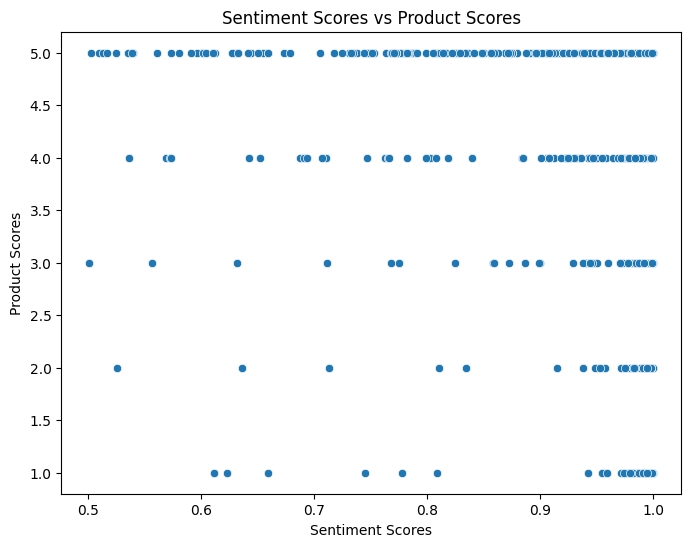

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns  # Make sure seaborn is imported

x = features_combined_df['sentiment_score_value']
y = features_combined_df['Score']

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='sentiment_score_value', y='Score', data=features_combined_df)  # Use data and column names
plt.title("Sentiment Scores vs Product Scores")
plt.xlabel("Sentiment Scores")
plt.ylabel("Product Scores")
plt.show()

In [69]:
features_combined_df = features_combined_df.rename(columns={'sentiment_score_label_POSITIVE': 'sentiment_score_label_POSITIVE_1'})
numeric_columns = features_combined_df.select_dtypes(include=[np.number]).columns
features_combined_df_numeric = features_combined_df[numeric_columns]

In [81]:
features_combined_df_numeric.columns = [
    f"{col}_{i}" if col == 'sentiment_score_label_POSITIVE_1' else col
    for i, col in enumerate(features_combined_df_numeric.columns)
]

print(features_combined_df_numeric.columns)  # Verify unique column names


Index(['sentiment_score_value', 'Score', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'text_length_characters', 'HelpfulnessRatio',
       'sentiment_score_label_POSITIVE_1_6',
       'sentiment_score_label_POSITIVE_1_7',
       'sentiment_score_label_POSITIVE_1_8',
       'sentiment_score_label_POSITIVE_1_9'],
      dtype='object')


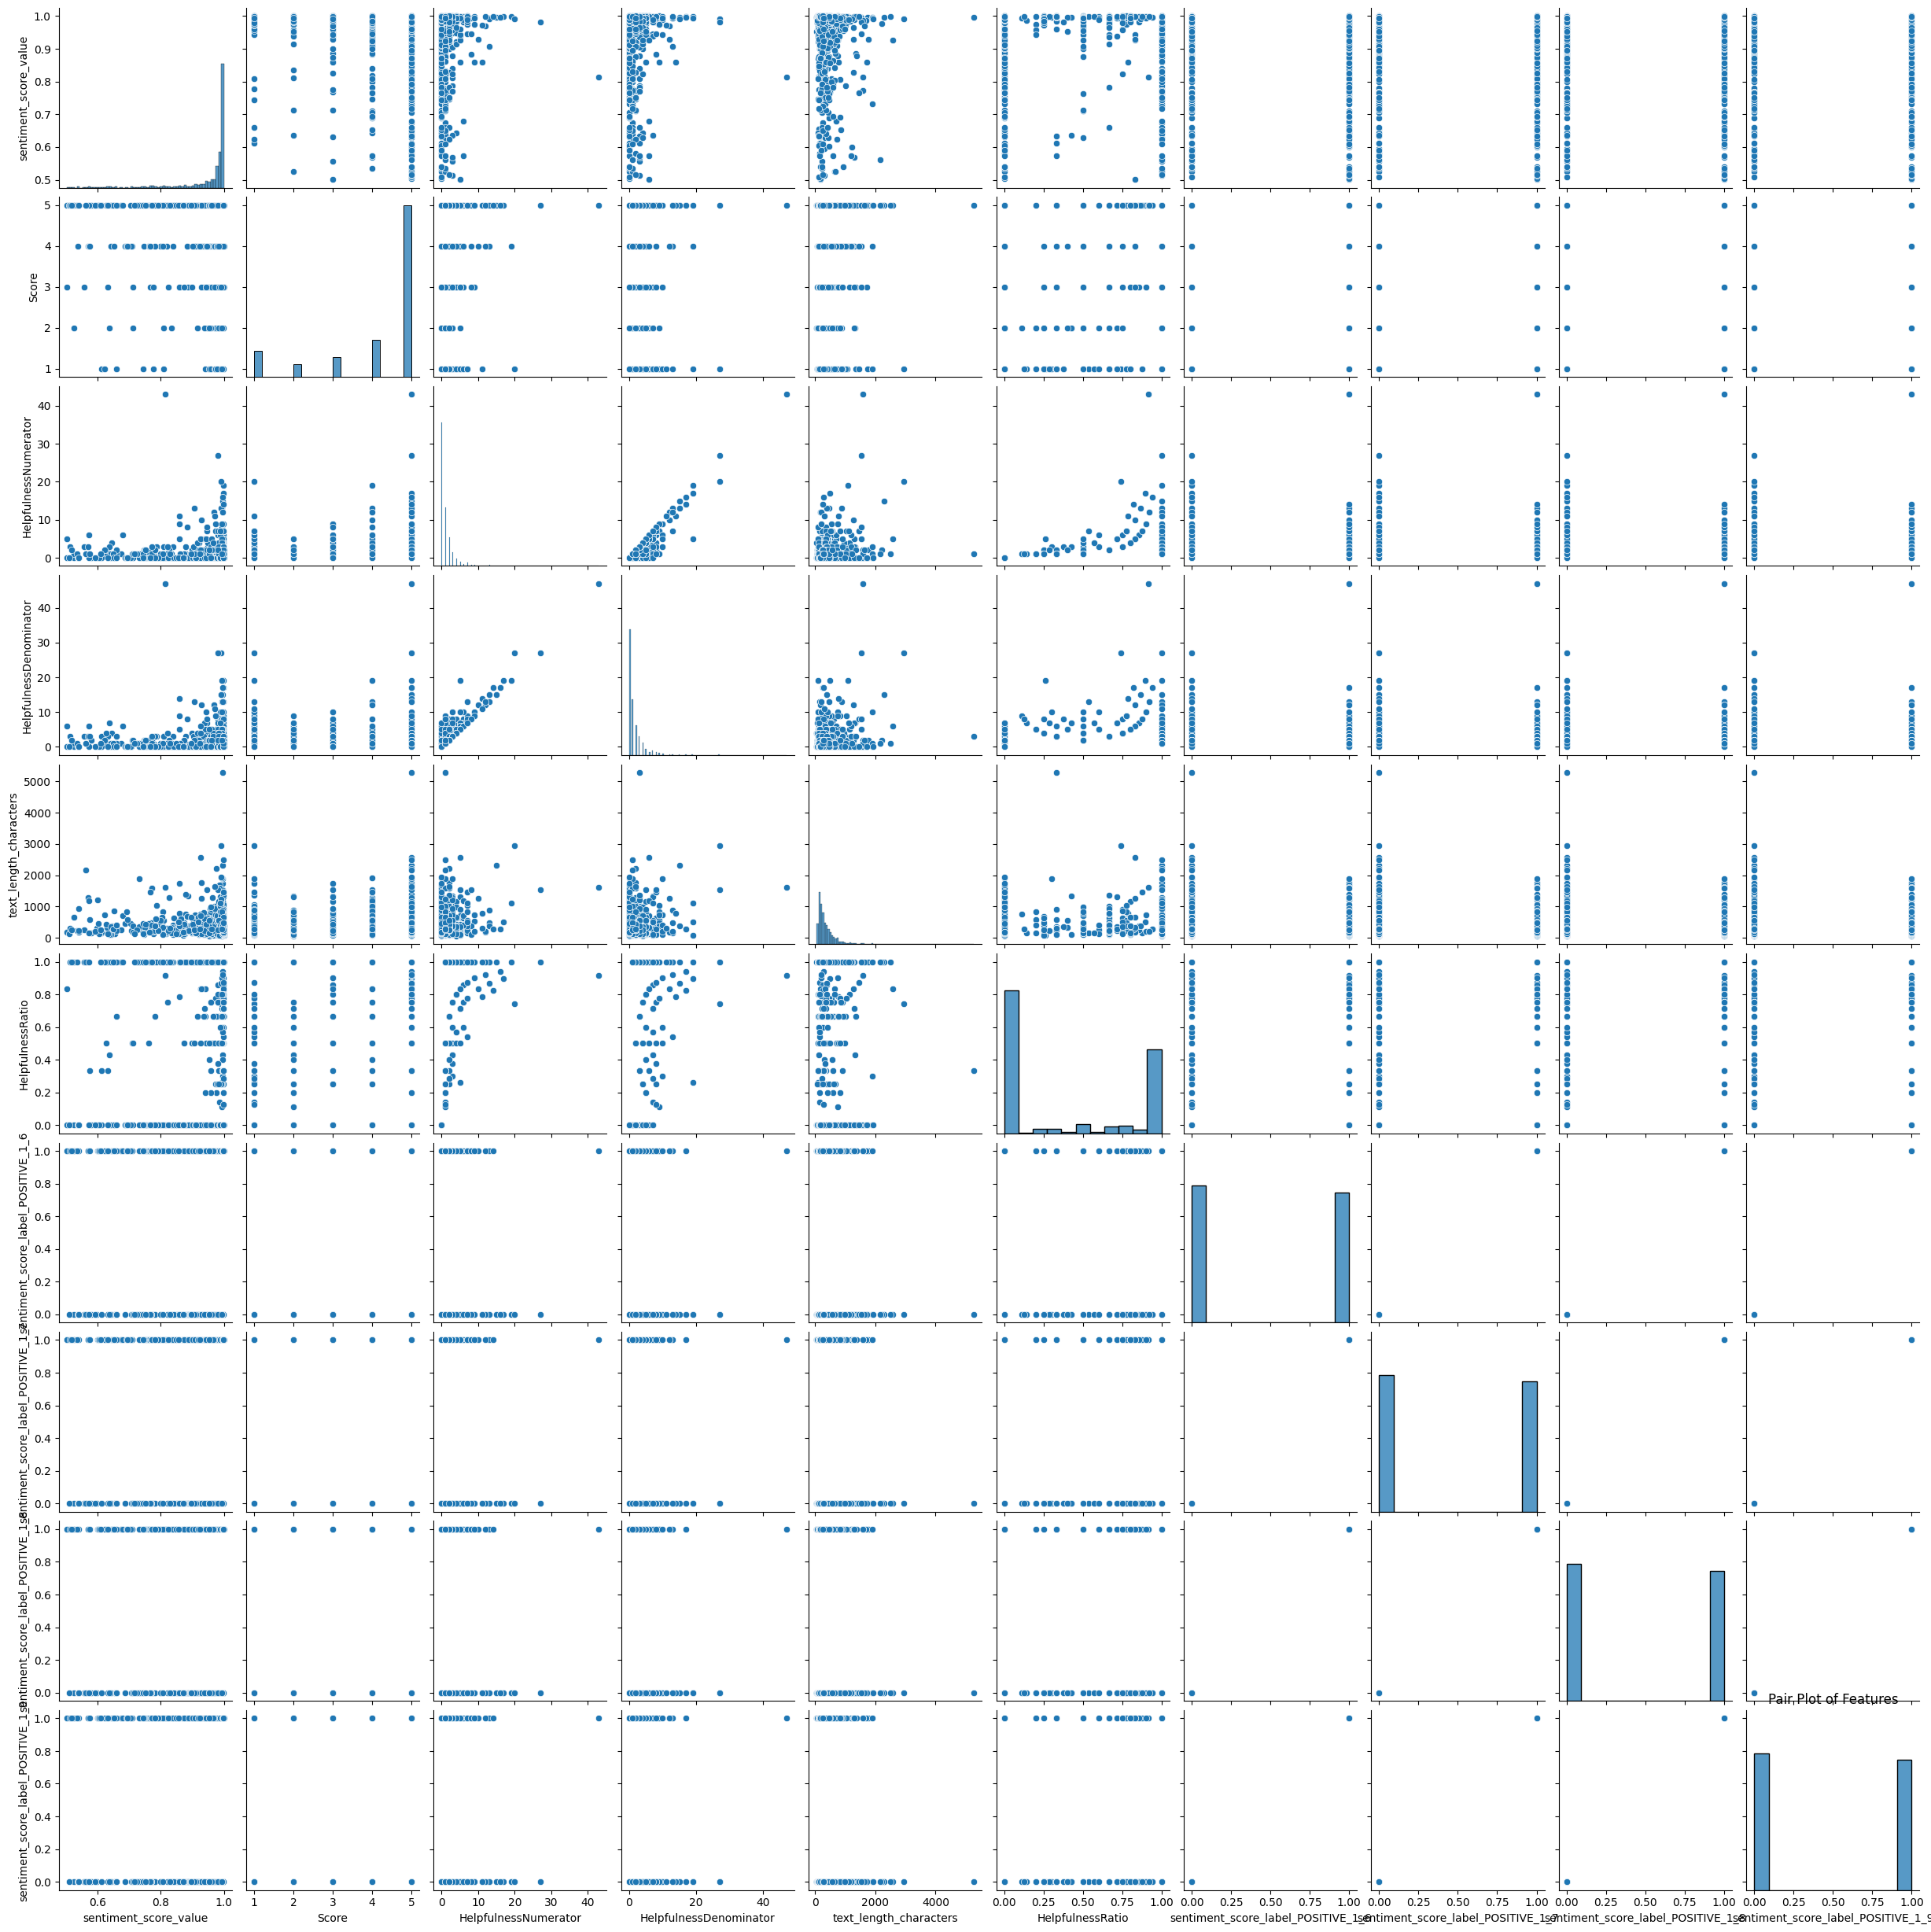

In [82]:
sns.pairplot(features_combined_df_numeric)
plt.title("Pair Plot of Features")
plt.show()

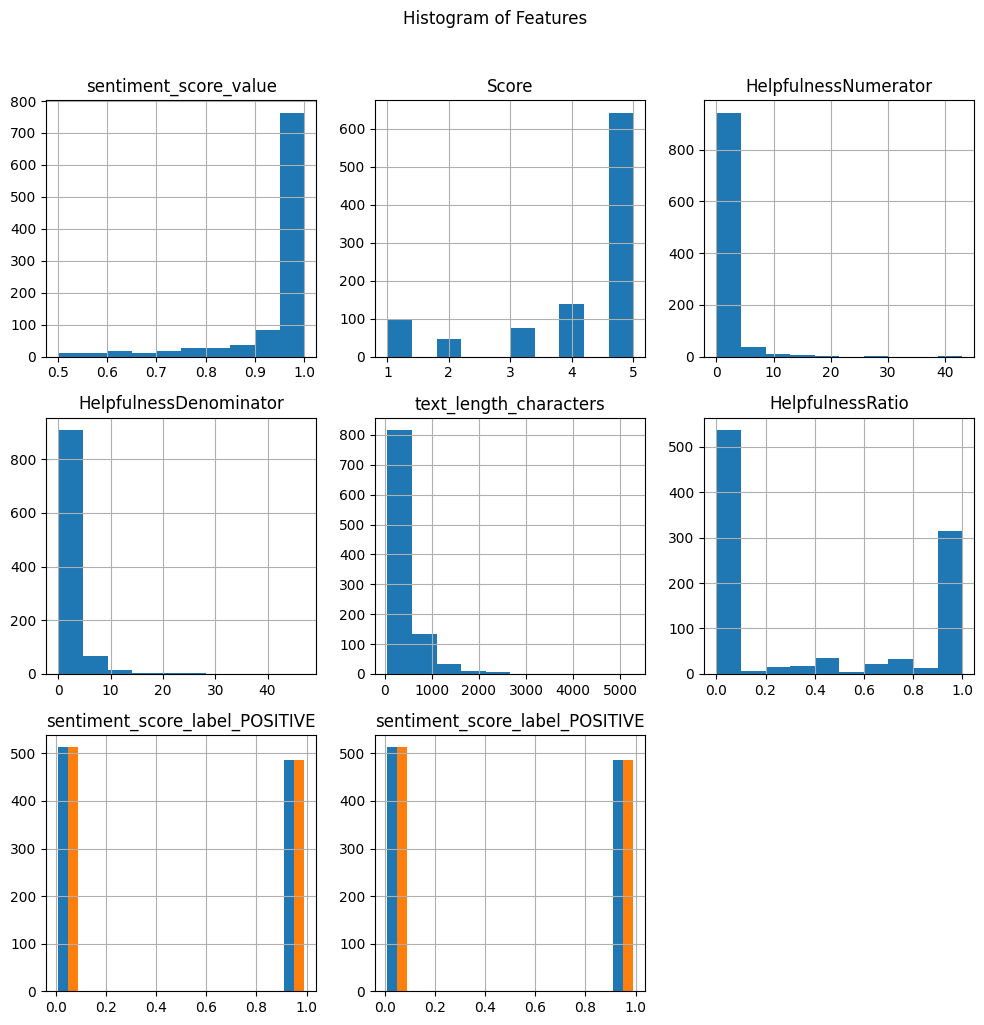

In [62]:
features_combined_df.hist(figsize=(10, 10))
plt.suptitle("Histogram of Features", y=1.02)
plt.tight_layout()
plt.show()

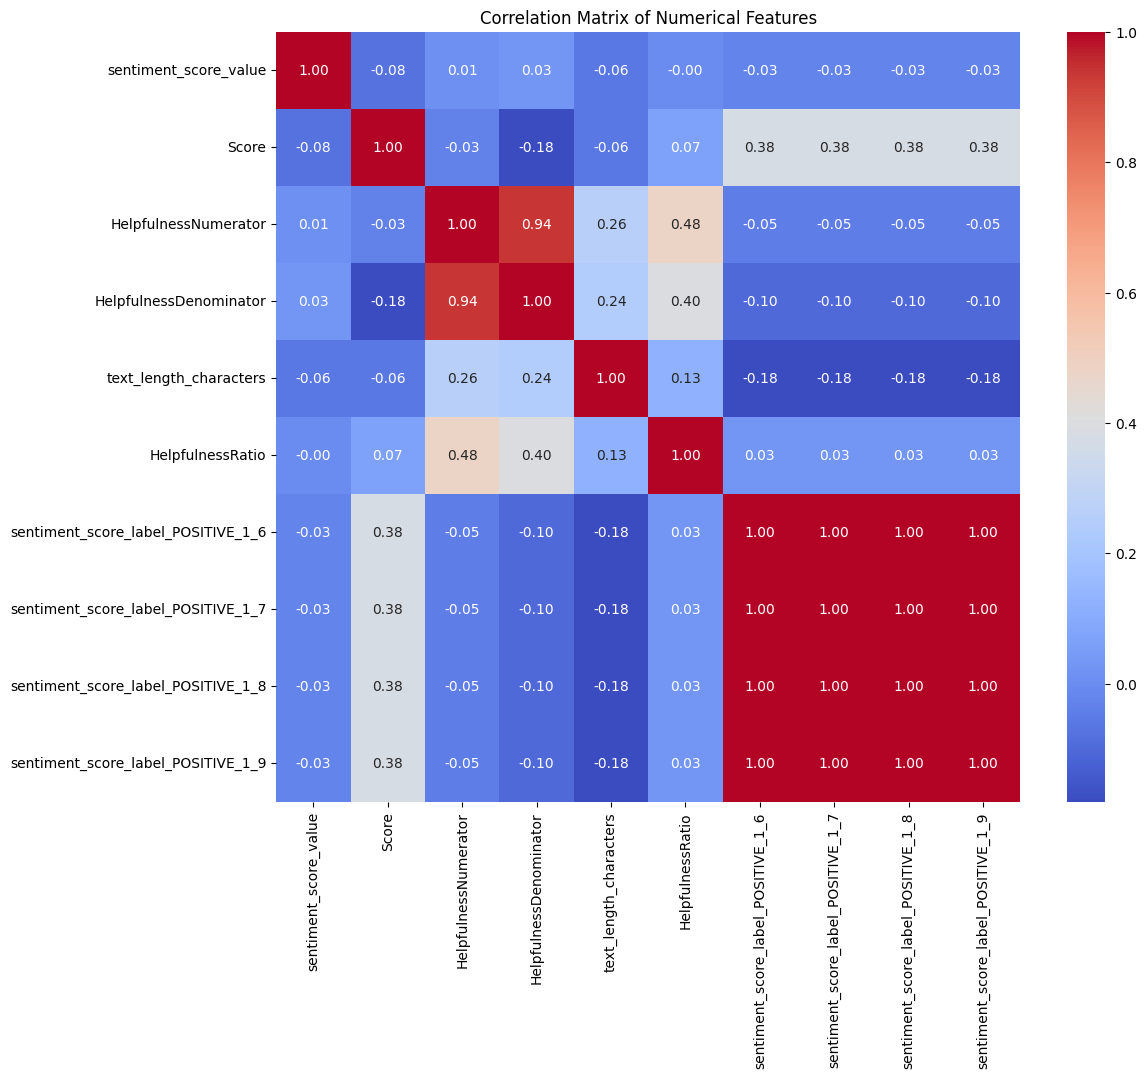

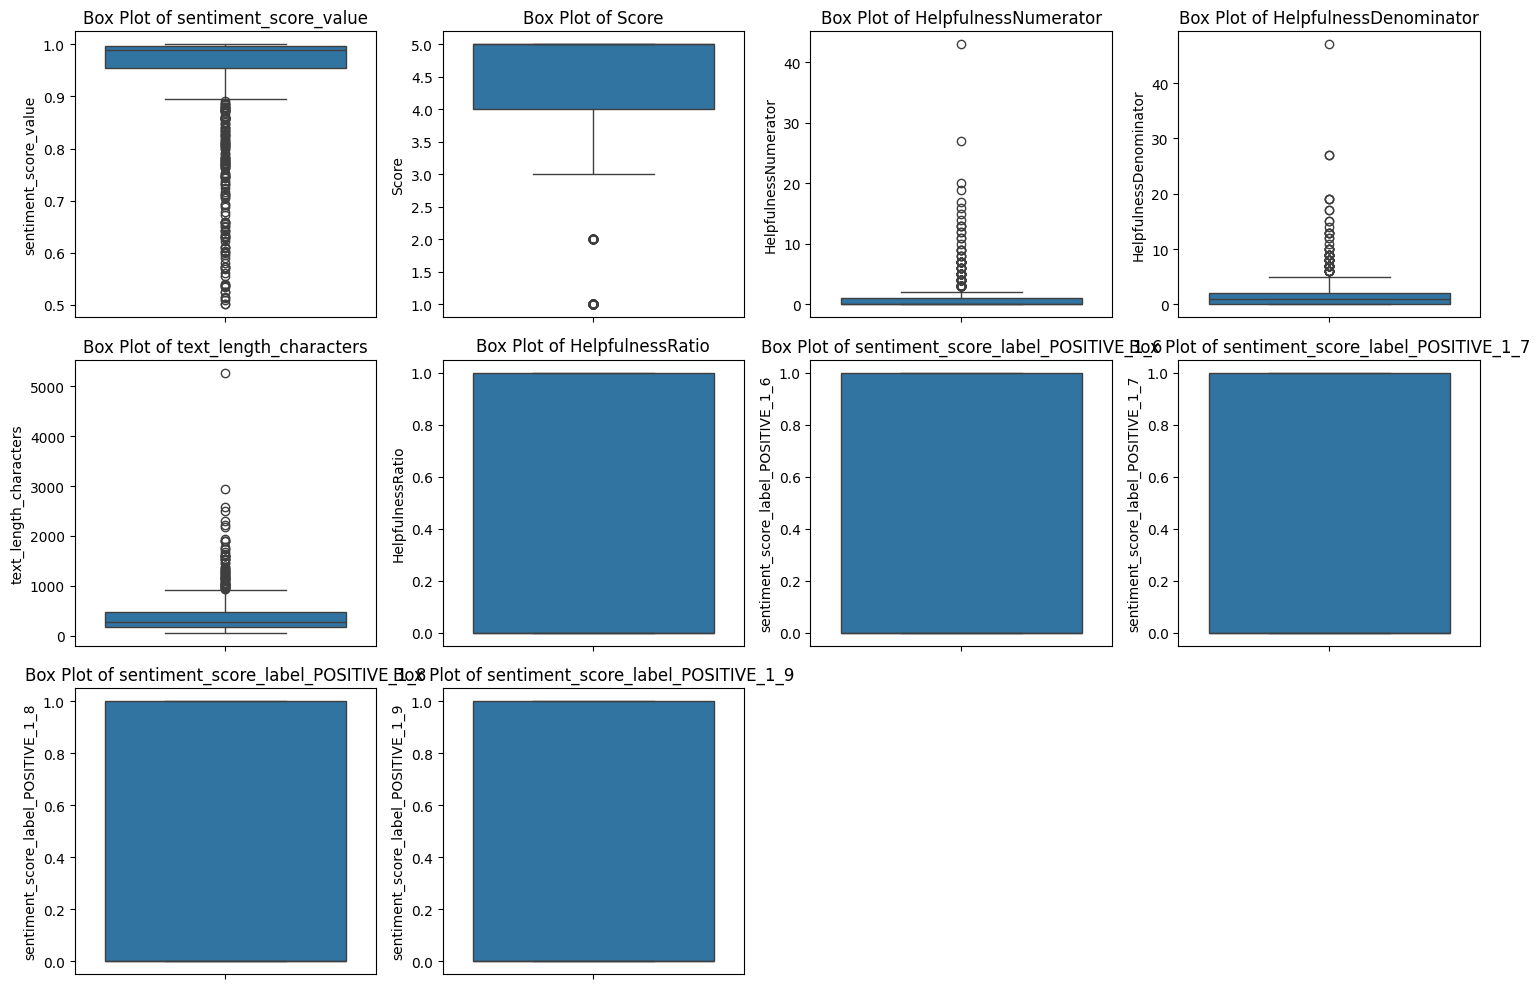

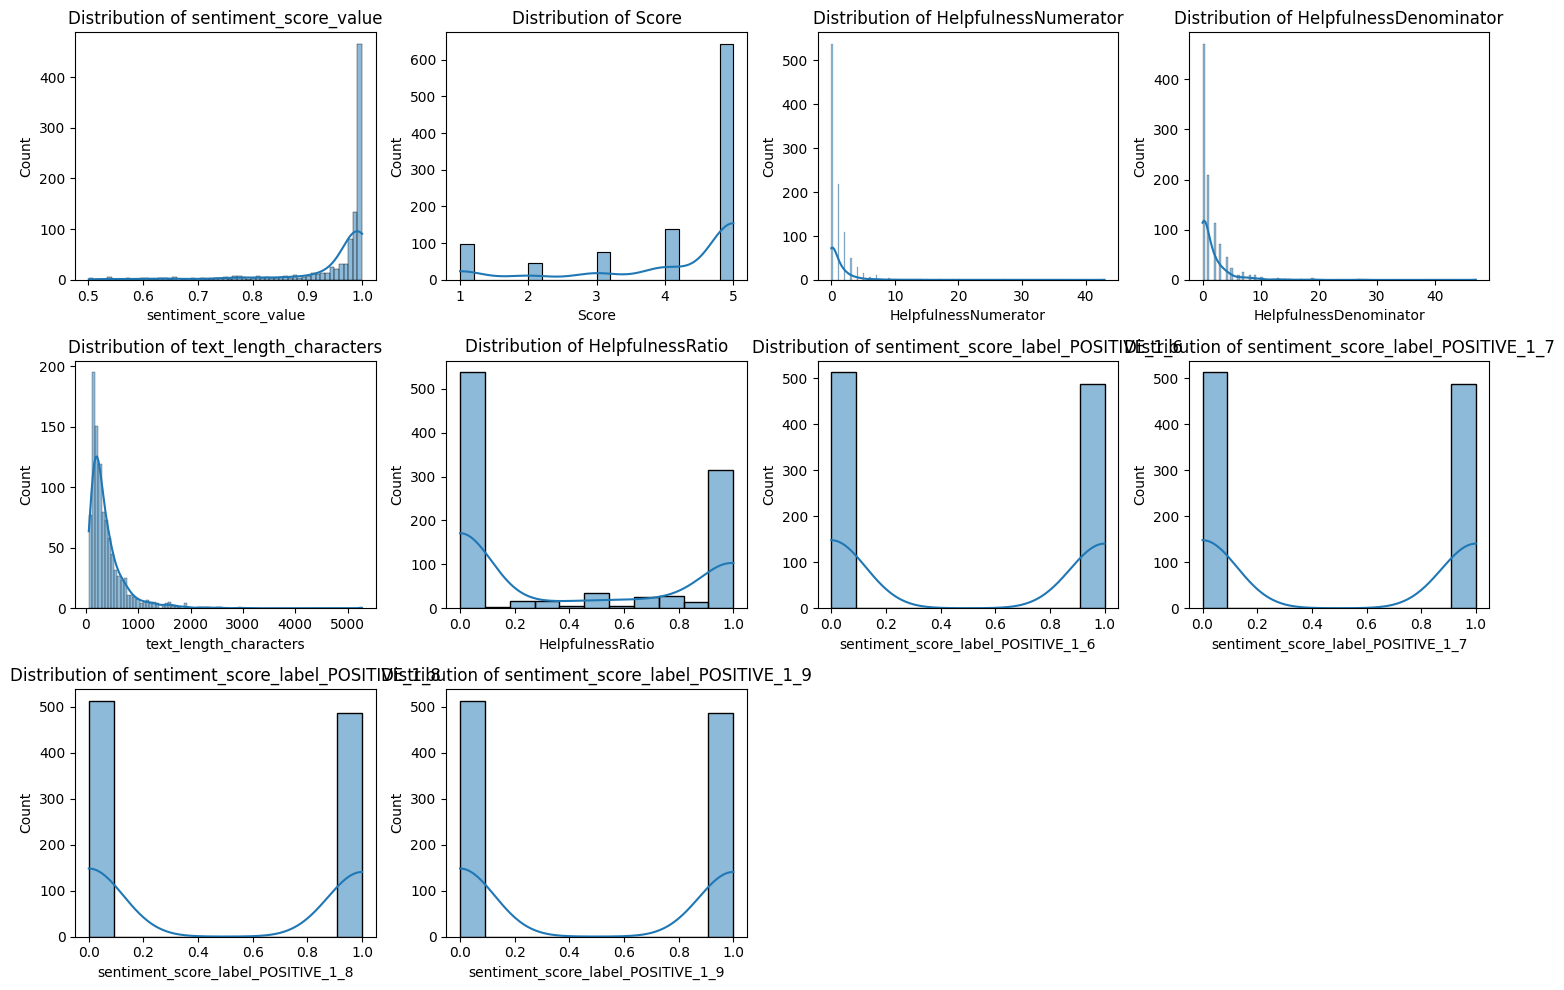

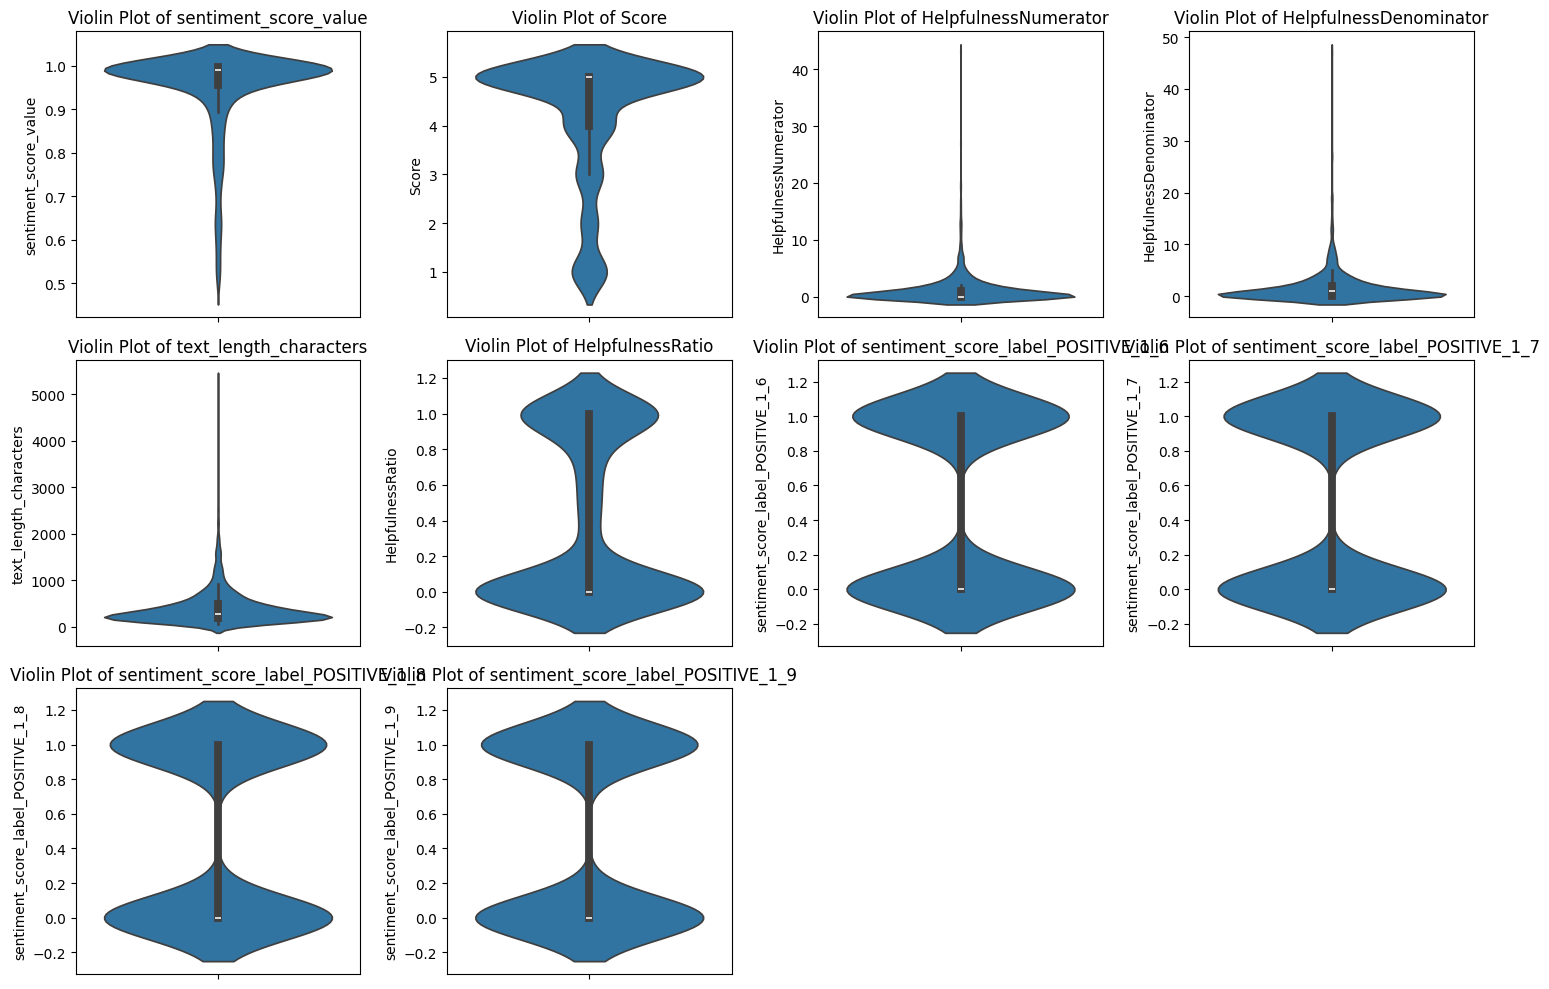

In [84]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = features_combined_df_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Box Plots for Numerical Features
plt.figure(figsize=(15, 10))
for i, col in enumerate(features_combined_df_numeric.columns):
    plt.subplot(3, 4, i + 1)  # Adjust the grid based on the number of features
    sns.boxplot(y=features_combined_df_numeric[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

# Distribution Plots for Numerical Features
plt.figure(figsize=(15, 10))
for i, col in enumerate(features_combined_df_numeric.columns):
    plt.subplot(3, 4, i + 1)  # Adjust the grid based on the number of features
    sns.histplot(features_combined_df_numeric[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Violin Plots
plt.figure(figsize=(15, 10))
for i, col in enumerate(features_combined_df_numeric.columns):
    plt.subplot(3, 4, i + 1)
    sns.violinplot(y=features_combined_df_numeric[col])
    plt.title(f"Violin Plot of {col}")
plt.tight_layout()
plt.show()